In [6]:
import sys, os, importlib
package_path = os.path.abspath('../..')    
if package_path not in sys.path:
    sys.path.append(package_path)
from package import functions as fn
from package import model as rm
from package import optimizer as opt
from package import plots
import numpy as np
import pandas as pd
import quaternion as npq
from obspy.taup import TauPyModel

np.set_printoptions(precision=4, suppress=True)
for module in [fn, rm, opt, plots]:
    importlib.reload(module)

In [7]:
M1 = np.array([[-0.412, 0.398, -1.239],
               [0.398, 0.084, 1.058],
               [-1.239, 1.058, 0.328]])

# get eigenvalues and eigenvectors, sorted in decreasing order of eigenvalues
evals, evecs = np.linalg.eig(M1)
idx = evals.argsort()[::-1]
evals = evals[idx]
evecs = evecs[:, idx]

# cross product of v1 and v2
if np.linalg.det(evecs) < 0:
    evecs[:, 0] = -evecs[:, 0]

print(np.linalg.inv(evecs))

[[-0.4041  0.4565  0.7927]
 [-0.6425 -0.7585  0.1093]
 [ 0.6511 -0.4651  0.5998]]


In [8]:
q1 = np.quaternion(1,2,3,4)
q2 = np.quaternion(5,6,7,8)
q1 * q2
a = np.array([q1, q2])
a

array([quaternion(1, 2, 3, 4), quaternion(5, 6, 7, 8)], dtype=quaternion)

In [9]:
U = np.array([[0.187, 0.879, -0.439],
              [-0.651, -0.224, -0.725],
              [-0.735, 0.421, 0.531]])
U

array([[ 0.187,  0.879, -0.439],
       [-0.651, -0.224, -0.725],
       [-0.735,  0.421,  0.531]])

In [10]:
q = npq.from_rotation_matrix(U)
q_array = npq.as_float_array(q)

# get max absolute value of q_array
max_abs = np.max(np.abs(q_array))
angle = np.rad2deg(2*np.arccos(max_abs))
angle

102.47992239947996

In [11]:
q.conjugate()

quaternion(0.61108635069417, -0.468944226090753, -0.121299333062793, 0.626060106227787)

Original params:  [  0.  45. -90.]


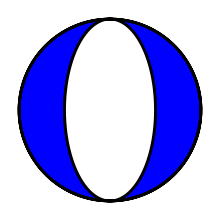

In [12]:
# generate synthetic data
t1, p1 = fn.i_hat, fn.k_hat

# get true params for synthetic test
true_params1 = fn.tp2sdr(t1, p1, True)[0]
print('Original params: ', true_params1)

# plot corresponding beachball
beachball = fn.beachball(true_params1)

Reversed fault params:  [315.  90.   0.]


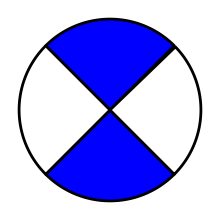

In [13]:
# reverse fault
t2, p2 = fn.j_hat, fn.i_hat
t2, p2 = fn.unit_vec(t2), fn.unit_vec(p2)
true_params2 = fn.tp2sdr(t2, p2, True)[0]
print('Reversed fault params: ', true_params2)

beachball2 = fn.beachball(true_params2)

In [14]:
# use the t and p to get orientation matrix
b1 = -np.cross(t1, p1)
b1 = fn.unit_vec(b1)
U1 = np.column_stack((t1, b1, p1))   

q1 = npq.from_rotation_matrix(U1)

b2 = -np.cross(t2, p2)
b2 = fn.unit_vec(b2)
U2 = np.column_stack((t2, b2, p2))
    
q2 = npq.from_rotation_matrix(U2)

# go from q1 to q2
q12 = q1.conjugate() * q2
q12_array = npq.as_float_array(q12)
max_abs = np.max(np.abs(q12_array))
angle = np.rad2deg(2*np.arccos(max_abs))
print('Angle between original and reversed fault: ', angle)

Angle between original and reversed fault:  119.99999999999999


In [15]:
U = np.linalg.inv(U1) @ U2
q = npq.from_rotation_matrix(U)
q_array = npq.as_float_array(q)
max_abs = np.max(np.abs(q_array))
angle = np.rad2deg(2*np.arccos(max_abs))
print('Angle between original and reversed fault: ', angle)

Angle between original and reversed fault:  119.99999999999999


In [16]:
np.array([t1+1, b1, p1])

array([[2., 1., 1.],
       [0., 1., 0.],
       [0., 0., 1.]])

In [17]:
importlib.reload(fn)

fn.sdr2kagan(true_params1, true_params2)

119.99999999999999

In [18]:
nwao = np.array([-1.90, 12.21, 35.51])
tau = np.array([-1.60, 20.45, -29.05])
makz = np.array([-7.54, 20.27, -42.09])
uln = np.array([-2.56, 29.56, -48.57])

cossim1 = fn.unit_vec(nwao) @ fn.unit_vec(tau)
cossim2 = fn.unit_vec(makz) @ fn.unit_vec(uln)
cossim1, cossim2

(-0.5824838463641998, 0.9886681297325481)